<a href="https://colab.research.google.com/github/BridgingAISocietySummerSchools/Python-for-Data-Science-Workshop/blob/main/01_introduction/05_pandas_intro.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 📊 First Steps with Pandas

> **Track:** Introduction Session — Notebook 5 of 5 · **Estimated time:** ~18 min · **Difficulty:** complete beginner

This is the finale, and the payoff. Notebooks 1–4 gave you the language: variables and f-strings, lists and dictionaries, `if`/`for`/`while`, and your own functions. Now you'll use it for what data scientists actually do all day: **load a table of data, ask it questions, and turn the answer into a chart.**

One real question drives the whole notebook:

> ❓ **Which countries look ready for the AI era — and what do numbers like these hide?**

We'll investigate twelve countries — population, internet access, and where AI startups are emerging — and finish with findings, a chart, *and* an honest list of what our data cannot tell us.

## 🎯 Learning objectives

By the end of this notebook you will be able to:

1. Say why **pandas** is the everyday tool of data science, and build a `DataFrame` both from a dictionary of lists and by **loading a CSV** with `pd.read_csv()`.
2. **Inspect** a table with `.shape`, `.head()`, `.info()` and `.describe()` — and say in plain words what you see.
3. **Select** a column, **filter** rows with a condition, add a **computed column**, **sort**, and **group**.
4. Turn a result into a labelled **matplotlib chart**, and practise *reading* charts, not just making them.

## ✅ Prerequisites

Notebooks 1–4 of this introduction session: [`01_welcome_to_python.ipynb`](01_welcome_to_python.ipynb) (variables, f-strings), [`02_data_structures.ipynb`](02_data_structures.ipynb) (lists, dictionaries, `len()`), [`03_control_flow.ipynb`](03_control_flow.ipynb) (comparisons, `if`/`for`/`while`) and [`04_functions.ipynb`](04_functions.ipynb) (calling functions, arguments, defaults).

⬅️ **Previous:** [`04_functions.ipynb`](04_functions.ipynb) · ➡️ **Next:** [`../02_advanced_self_learning/01_python_basics.ipynb`](../02_advanced_self_learning/01_python_basics.ipynb)

## 1. From single values to tables

So far our data has lived in single variables and lists. Real data almost never looks like that. Patients in a study, survey respondents, sensor readings, countries in a report — real data comes as a **table**: one row per *thing*, one column per *property*.

The dictionaries from Notebook 2 are the stepping stone. One dictionary describes **one** thing. Flip the idea around — every key becomes a **column name**, every value a **list** with one entry per row — and you have a whole table.

The library that turns that into a proper table object is **pandas**, the tool data scientists reach for every single day. A **library** is somebody else's code that you borrow: `import pandas as pd` loads it and gives it the short nickname `pd` — every pandas user in the world writes exactly that line. Its table is called a **DataFrame**, and everything you do to one is a *function call* on the object (Notebook 4), written `df.something(...)`.

In [2]:
import pandas as pd

# One dictionary = the facts about ONE thing (Notebook 2)
germany = {"country": "Germany", "population_millions": 84.5}

# A dictionary of LISTS = a whole table: every key becomes a column
mini = pd.DataFrame({
    "country": ["Germany", "France", "Estonia"],
    "population_millions": [84.5, 68.2, 1.4],
})
mini   # the last line of a cell is displayed automatically

,country,population_millions
0,Germany,84.5
1,France,68.2
2,Estonia,1.4


## 2. How data really arrives: `pd.read_csv()`

Typing data by hand is fine for three rows, hopeless for three thousand. In real work, data arrives as a **file** — most often a **CSV** ("comma-separated values"): a plain-text table, one row per line, columns separated by commas. Spreadsheets, databases, statistical agencies and web APIs all export it.

Loading one is a single line:

```python
df = pd.read_csv("countries.csv")                          # a file on disk
df = pd.read_csv("https://example.org/countries.csv")      # ...or a URL
```

**In real work that argument is a file path or a URL.** Below we inline the CSV *text* and hand it to `pd.read_csv()` through `io.StringIO`, which lets pandas read a string as if it were a file — so this notebook runs anywhere, with no downloads and nothing to install. Everything after this cell is exactly what you would do with a real file.

> ℹ️ The numbers are **illustrative** — plausible in scale but simplified for teaching. Don't cite them!

In [3]:
import io

csv_text = """country,continent,population_millions,internet_users_pct,ai_startups_per_million
Germany,Europe,84.5,93.0,8.2
France,Europe,68.2,92.0,7.5
Estonia,Europe,1.4,92.0,15.0
United States,Americas,335.0,92.0,18.5
Canada,Americas,39.0,94.0,12.4
Brazil,Americas,216.0,84.0,2.1
India,Asia,1430.0,52.0,1.2
Japan,Asia,124.0,84.0,3.8
South Korea,Asia,51.7,97.0,9.6
Nigeria,Africa,224.0,42.0,0.4
Kenya,Africa,55.1,40.0,0.9
South Africa,Africa,60.4,72.0,1.5
"""

# In real work:  df = pd.read_csv("countries.csv")
df = pd.read_csv(io.StringIO(csv_text))   # here: read the text above as if it were a file
df                                        # "df" is the traditional name for a DataFrame

,country,continent,population_millions,internet_users_pct,ai_startups_per_million
0,Germany,Europe,84.5,93.0,8.2
1,France,Europe,68.2,92.0,7.5
2,Estonia,Europe,1.4,92.0,15.0
3,United States,Americas,335.0,92.0,18.5
4,Canada,Americas,39.0,94.0,12.4
5,Brazil,Americas,216.0,84.0,2.1
6,India,Asia,1430.0,52.0,1.2
7,Japan,Asia,124.0,84.0,3.8
8,South Korea,Asia,51.7,97.0,9.6
9,Nigeria,Africa,224.0,42.0,0.4


## 3. First look: never analyse what you haven't seen

Rule number one of data analysis: **look at your data before you compute anything.** pandas gives you a standard four-move opening:

- `df.shape` — how big is this? *(rows, columns)*
- `df.info()` — the column names, their **data types**, and how many values are actually present
- `df.head()` — the first few rows: *is this the data I think it is?* (`df.tail()` shows the last ones)
- `df.describe()` — summary statistics for every numeric column

In [4]:
print("Shape (rows, columns):", df.shape)

df.info()

df.head()   # the first 5 rows

Shape (rows, columns): (12, 5)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12 entries, 0 to 11
Data columns (total 5 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   country                  12 non-null     object 
 1   continent                12 non-null     object 
 2   population_millions      12 non-null     float64
 3   internet_users_pct       12 non-null     float64
 4   ai_startups_per_million  12 non-null     float64
dtypes: float64(3), object(2)
memory usage: 612.0+ bytes


,country,continent,population_millions,internet_users_pct,ai_startups_per_million
0,Germany,Europe,84.5,93.0,8.2
1,France,Europe,68.2,92.0,7.5
2,Estonia,Europe,1.4,92.0,15.0
3,United States,Americas,335.0,92.0,18.5
4,Canada,Americas,39.0,94.0,12.4


**Reading that output.** `df.shape` says `(12, 5)`: **12 rows** (one per country) and **5 columns** (one per property). Rows first, columns second — always.

`info()` adds two things a data scientist checks *first*:

- **Dtype** — the type pandas guessed for each column. `object` means text, `float64` means decimal numbers. Check this first, because it decides what you are allowed to do: you can average a `float64`, you cannot average an `object`.
- **Non-Null Count** — how many real values each column has. Here every column says `12 non-null`, so nothing is missing. When that number is smaller than the row count, you have gaps to deal with (a Track-2 topic).

And `head()` confirms the obvious-but-essential thing: the rows really are countries, the names came through as text and the numbers as numbers. Look at **row 0** — it is the `germany` dictionary from section 1, laid on its side. That is all a DataFrame is: one dictionary's worth of facts per row, stacked into a table.


In [5]:
df.describe()   # count, mean, spread, min/max — for every numeric column

,population_millions,internet_users_pct,ai_startups_per_million
count,12.000000,12.000000,12.000000
mean,224.108333,77.833333,6.758333
std,391.884720,21.221059,6.120526
min,1.400000,40.000000,0.400000
25%,54.250000,67.000000,1.425000
50%,76.350000,88.000000,5.650000
75%,218.000000,92.250000,10.300000
max,1430.000000,97.000000,18.500000


**Reading `describe()`.** Two things jump out even from this tiny table:

- The **mean** population is about 224 million, but the **median** (the `50%` row) is only about 76 million. A few giants — India, the United States — pull the average up. When mean and median disagree, your data is *skewed*: a classic first insight.
- Internet access ranges from **40% to 97%**. That spread is a story in itself, and we'll come back to it.

## 4. Asking one question: selecting a column

A column answers one question about *all* countries at once. You select it with square brackets and the column name — exactly like getting a value out of a dictionary. What comes back behaves like a list of numbers with superpowers: built-in statistics such as `.mean()` and `.max()`.

In [6]:
internet = df["internet_users_pct"]

print(f"Average internet access : {internet.mean():.1f}%")
print(f"Highest internet access : {internet.max():.1f}%")

# But WHICH country is at 97%? Hold that thought — sorting (section 6) will tell us.

Average internet access : 77.8%
Highest internet access : 97.0%


## 5. Filtering: the `if` of whole tables

In Notebook 3 you wrote conditions like `if internet_pct >= 90:` to check **one** value. Filtering is the same idea applied to **every row at once**: put the condition inside the square brackets, and pandas keeps only the rows where it is `True`. (Notebook 2's `len()` works on a table too — there it counts the **rows**.)

In [7]:
# Which countries have at least 90% of their population online?
well_connected = df[df["internet_users_pct"] >= 90]

print(f"{len(well_connected)} of {len(df)} countries are 'well connected':")
well_connected

6 of 12 countries are 'well connected':


,country,continent,population_millions,internet_users_pct,ai_startups_per_million
0,Germany,Europe,84.5,93.0,8.2
1,France,Europe,68.2,92.0,7.5
2,Estonia,Europe,1.4,92.0,15.0
3,United States,Americas,335.0,92.0,18.5
4,Canada,Americas,39.0,94.0,12.4
8,South Korea,Asia,51.7,97.0,9.6


### 🎯 Try it (1–2 min) — Population giants

Filter the table to show only the **population giants**: countries with more than 100 million inhabitants. How many are there?

In [7]:
# Your turn 👇

<details><summary>💡 Click to reveal the solution</summary>

```python
giants = df[df["population_millions"] > 100]
print(f"{len(giants)} giants:")
giants
```

The condition `df["population_millions"] > 100` uses exactly the comparison operators from Notebook 3 — only now the comparison runs on the whole column at once and produces a `True`/`False` per row. Putting that inside `df[...]` keeps the `True` rows: **5 giants** — the United States, Brazil, India, Japan and Nigeria.

</details>

### 💬 Discuss (30 seconds, with your neighbour)

Where do you meet data like this in **your** field — and what would the rows and columns be? Patients and lab values? Historical texts and word counts? Sensors and measurements?

## 6. Simple manipulation: computed columns, sorting, grouping

Three more moves and you can answer surprisingly sophisticated questions.

**A computed column** comes first, and it's the workhorse of real analysis: combine existing columns into the number you actually care about. Our table has a *percentage* online and a *population* — multiply them and we get something new: how many people are online in **absolute** terms.

In [8]:
# population (millions) × share online (%) ÷ 100 = internet users in millions
df["internet_users_millions"] = (df["population_millions"] * df["internet_users_pct"] / 100).round(1)

df[["country", "population_millions", "internet_users_pct", "internet_users_millions"]].head()

,country,population_millions,internet_users_pct,internet_users_millions
0,Germany,84.5,93.0,78.6
1,France,68.2,92.0,62.7
2,Estonia,1.4,92.0,1.3
3,United States,335.0,92.0,308.2
4,Canada,39.0,94.0,36.7


Assigning to `df["new_name"]` **creates** the column; pandas does the arithmetic for all 12 rows at once — no loop needed — and `.round(1)` tidies the result to one decimal. The table now has 6 columns instead of 5. (The *double* brackets in the last line are just a **list** of column names inside the usual selection brackets: that is how you ask for several columns at once.)

Now, **`sort_values`** puts rows in order, so the top of the table answers *"who is number one?"* — and `ascending=False` names an option by name, the same `name=value` shape you met in `def tip(amount, rate=0.1)` in Notebook 4.


In [9]:
df.sort_values("internet_users_millions", ascending=False).head(3)

,country,continent,population_millions,internet_users_pct,ai_startups_per_million,internet_users_millions
6,India,Asia,1430.0,52.0,1.2,743.6
3,United States,Americas,335.0,92.0,18.5,308.2
5,Brazil,Americas,216.0,84.0,2.1,181.4


**A finding, from one computed column.** By *share* of the population, India (52%) sits near the bottom of our table. By *absolute number of people online* it is far and away number one — roughly 744 million, more than the United States and Brazil combined. Same data, two different questions, two different leaders. Choosing which number to report is an editorial decision, not a technical one.

*(And the 97% mystery from section 4? Sort by `"internet_users_pct"` instead and the same one-liner names it: **South Korea**.)*

Finally, **`groupby`** splits the table into groups and computes one number per group. *"What's the average X per Y?"* is the single most common question in data analysis.

In [10]:
# Average internet access per continent — split, average, done
df.groupby("continent")["internet_users_pct"].mean().round(1).sort_values(ascending=False)

continent
Europe      92.3
Americas    90.0
Asia        77.7
Africa      51.3
Name: internet_users_pct, dtype: float64

**Reading the result.** Twelve rows in, four numbers out — and those four numbers tell a story: in our illustrative table Europe and the Americas average around 90% internet access, Asia sits in the high 70s, and our African sample around 51%. That is the *digital divide*, summarised in one line of code.

## 7. The chart: a sentence about data

A table of numbers makes the reader do the work. A good chart **is a sentence about data**: it states *one* message — here, "AI startup density varies enormously between countries" — clearly enough that a reader gets it in two seconds. Let's write that sentence with **matplotlib**, Python's standard plotting library.

> 🎨 The colours below are the Bridging AI & Society summer-school palette, so every chart in this course looks like part of one family.

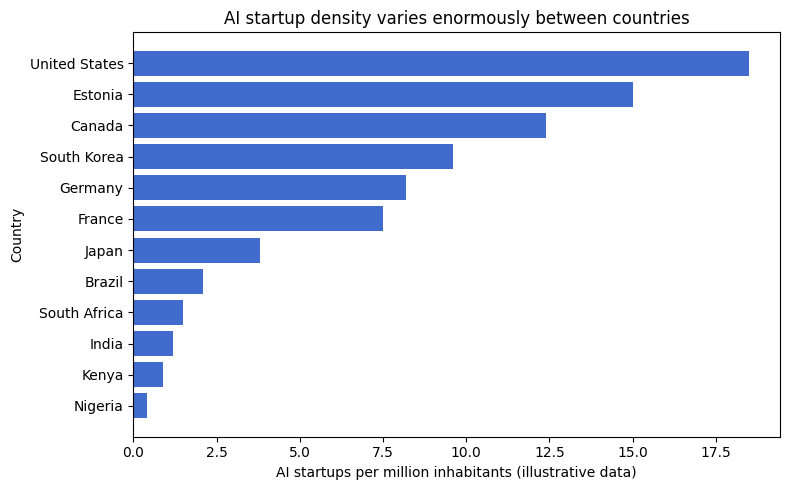

In [11]:
# --- Bridging AI & Society course plot style -------------------------------
BAS_BLUE = "#416bcc"   # brand accent (lapis blue) — primary series
BAS_INK  = "#1c2025"   # brand ink — text/edges where needed
# supporting colours, chosen to sit well next to the lapis accent:
BAS_AMBER  = "#d9822b"   # secondary series / contrast
BAS_GREEN  = "#3a9e6e"   # "good" / positive
BAS_RED    = "#c8504f"   # "bad" / warnings / errors
BAS_PURPLE = "#7a5fb5"   # tertiary series
BAS_GREY   = "#8a919c"   # de-emphasised / reference lines
BAS_PALETTE = [BAS_BLUE, BAS_AMBER, BAS_GREEN, BAS_RED, BAS_PURPLE, BAS_GREY]

import matplotlib.pyplot as plt
plt.rcParams["axes.prop_cycle"] = plt.cycler(color=BAS_PALETTE)

# Sort ascending so the longest bar ends up at the TOP of the chart
by_density = df.sort_values("ai_startups_per_million")

plt.figure(figsize=(8, 5))
plt.barh(by_density["country"], by_density["ai_startups_per_million"], color=BAS_BLUE)
plt.xlabel("AI startups per million inhabitants (illustrative data)")
plt.ylabel("Country")
plt.title("AI startup density varies enormously between countries")
plt.tight_layout()
plt.show()

### How to read a chart — and then make one

Making charts is easy; *reading* them well is the real skill. Three moves, always in this order:

1. **Axes first.** What is measured, in what units? Here: AI startups *per million inhabitants* — a density, not a count. Skipping this step is how charts fool people.
2. **Shape second.** Squint. The bars don't shrink gradually: a small cluster at the top (United States, Estonia, Canada), then a long tail. The *gap* is the message.
3. **Surprises last.** Anything against expectation? The population giants India and Nigeria — over 1.6 billion people between them — sit near the very bottom, and the top of the chart looks a lot like the "well connected" filter from section 5.

Note also what *per million* does: Estonia, with 1.4 million people, ranks second. Per-capita measures level the field between big and small countries, but they can also **over-reward the small**.

### 🎯 Try it (1–2 min) — Your own chart

Make the same chart for **internet access**: copy the cell above and change the column to `"internet_users_pct"` (it appears once in `sort_values`, once in `plt.barh`). Update the axis label and the title too — a chart with the wrong labels is a false sentence!


In [12]:
# Your turn 👇

<details><summary>💡 Click to reveal the solution</summary>

```python
by_internet = df.sort_values("internet_users_pct")

plt.figure(figsize=(8, 5))
plt.barh(by_internet["country"], by_internet["internet_users_pct"], color=BAS_AMBER)
plt.xlabel("Internet users (% of population, illustrative data)")
plt.ylabel("Country")
plt.title("Internet access ranges from 40% to 97% across our sample")
plt.tight_layout()
plt.show()
```

Only two kinds of change were needed: the column name (twice) and the words on the chart. The *recipe* — sort, `barh`, label, title — is identical, which is why copying and adapting working code is a perfectly professional habit. `BAS_AMBER` marks it as a different series from the blue chart above.

Now apply the three reading moves: axes (a percentage of population, not absolute numbers), shape (South Korea tops out at 97%, Kenya and Nigeria sit near 40%), surprises (the gap in the middle *is* the digital divide from section 6 — one bar per country instead of one number per continent).

</details>

### 💬 Discuss (30 seconds, with your neighbour)

What could be **misleading** about comparing countries this way? Who counted the "AI startups", and would every country count the same way? Is "per million inhabitants" fair to a country the size of Estonia? What does a single national average hide — cities vs. countryside, young vs. old?

Why it matters: numbers exactly like these feed "AI readiness" rankings, headlines about the global AI race, and real funding decisions — and AI systems are trained on whatever data happened to get collected, gaps and blind spots included. Asking these questions is part of the job, whether you build the analysis or the AI.

## 8. So — which countries look ready for the AI era?

Three findings, in our illustrative data:

1. **Populations are wildly skewed** — the mean (224M) is nearly triple the median (76M), because a few giants pull the average up. Averages always need a second look.
2. **The digital divide is continental**: internet access averages around 90% in Europe and the Americas but roughly 51% in our African sample — and one computed column showed that the *largest* population online is nonetheless India's.
3. **AI startup density concentrates in small-to-mid-sized, wealthy, highly connected countries** — not in the population giants. "Ready for the AI era" apparently has more to do with connectivity than with size.

Just as important is what the data **cannot** tell us: *why* these gaps exist, what a national average hides, or whether "startups per million" measures innovation at all. A finished analysis states its findings *and* its limits — and you have just done both.


## 🧠 Key takeaways

1. Real data comes as **tables**. A dictionary of lists is Python's doorway; `pd.read_csv("file.csv")` is how data actually arrives — the argument is a path or a URL.
2. **Look first**: `.shape` (rows, columns), `.info()` (dtypes and non-null counts — check dtypes *first*), `.head()`, `.describe()`.
3. `df["column"]` selects one question; `.mean()` and `.max()` answer it.
4. **Filtering** — `df[df["col"] > x]` — is the `if` of tables.
5. Assigning to `df["new"]` adds a **computed column**; `sort_values` finds the leaders; `groupby` computes one number per category.
6. A chart is a **sentence about data**: one message, honest labels. Read charts in three moves — axes, shape, surprises.
7. An analysis isn't finished until you've said **in plain words** what the results mean: findings *and* limits.

## ✅ Self-assessment

Tick what you can honestly check — the self-paced track revisits every one of these in depth:

- [ ] I can load a CSV into a DataFrame with `pd.read_csv()` and explain what the argument would be in real work.
- [ ] I can inspect a table with `.shape`, `.info()`, `.head()` and `.describe()` — and say in words what I see, including why dtypes matter.
- [ ] I can select a column and compute its mean and maximum.
- [ ] I can filter rows with a condition.
- [ ] I can add a computed column, sort a table, and group it by a category.
- [ ] I can make a labelled bar chart with matplotlib — and read one using axes → shape → surprises.

## 🚀 Where to go from here

**You've completed the 90-minute introduction session — congratulations! 🎉** An hour and a half ago you may never have written a line of Python. Since then you have met the language, built lists and dictionaries, made the computer decide and repeat, written your own functions, and just now loaded a real table, questioned it, computed a new column, grouped it and charted it. That loop — *data → questions → chart* — is the daily rhythm of data science. Everything else is refinement.

**One optional extra, if there is time — or on the train home.** The chart above took eight lines of matplotlib. [`06_seaborn_intro.ipynb`](06_seaborn_intro.ipynb) is a ten-minute bonus notebook that draws it in one, with **seaborn** — the library that plots straight from a DataFrame, colours by category and writes the legend for you. It runs on its own and assumes only what you have just done.

And refinement is what comes next. Your self-study path is the **[`../02_advanced_self_learning/`](../02_advanced_self_learning/)** track: **15 self-paced notebooks** that revisit everything from today in depth and then keep going — **NumPy**, **pandas in depth**, **data cleaning**, **visualisation with matplotlib and seaborn**, **exploratory data analysis**, **machine learning with scikit-learn**, an **introduction to PyTorch**, and a **capstone project** of your own.

- Start at the beginning: [`../02_advanced_self_learning/01_python_basics.ipynb`](../02_advanced_self_learning/01_python_basics.ipynb)
- Or go straight back to pandas, in depth: [`../02_advanced_self_learning/07_pandas_essentials.ipynb`](../02_advanced_self_learning/07_pandas_essentials.ipynb)
- Or straight to charts, in depth: [`../02_advanced_self_learning/09_visualization_matplotlib.ipynb`](../02_advanced_self_learning/09_visualization_matplotlib.ipynb) and [`../02_advanced_self_learning/10_visualization_seaborn.ipynb`](../02_advanced_self_learning/10_visualization_seaborn.ipynb)

Every notebook runs in **Google Colab**, free and in your browser with nothing to install. Take your time, run every cell, and change the numbers to see what happens. That's how this gets to be fun. 🐍📊
